In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [7]:
k = 3

df = pd.read_csv(
    f"../results/kmers/k{k}_book_counts.tsv",
    sep="\t"
)

df.head()

,language,book,k,kmer,count,frequency
0,dutch,camera_obscura,3,PRO,118,0.000324
1,dutch,camera_obscura,3,ROD,23,0.000063
2,dutch,camera_obscura,3,ODU,19,0.000052
3,dutch,camera_obscura,3,DUC,29,0.000080
4,dutch,camera_obscura,3,UCE,39,0.000107


In [8]:
df.shape

(121306, 6)

In [9]:
df["language"].value_counts()

language
english    24234
swedish    18068
dutch      17112
turkish    16582
french     16272
polish     16083
german     12955
Name: count, dtype: int64

In [10]:
df["book"].nunique()

22

In [17]:
df.groupby("language")["book"].nunique()

language
dutch      3
english    4
french     3
german     3
polish     3
swedish    3
turkish    3
Name: book, dtype: int64

In [19]:
book_sizes = (
    df.groupby(["language", "book"])["count"]
      .sum()
      .reset_index(name="total_kmers")
)

book_sizes

,language,book,total_kmers
0,dutch,camera_obscura,363852
1,dutch,max_havelaar,587261
2,dutch,sara_burgerhart,60163
3,english,alice,108081
4,english,mobydick,955176
5,english,pride,563937
6,english,sherlock,431475
7,french,candide,157607
8,french,madame_bovary,512875
9,french,notre_dame,826232


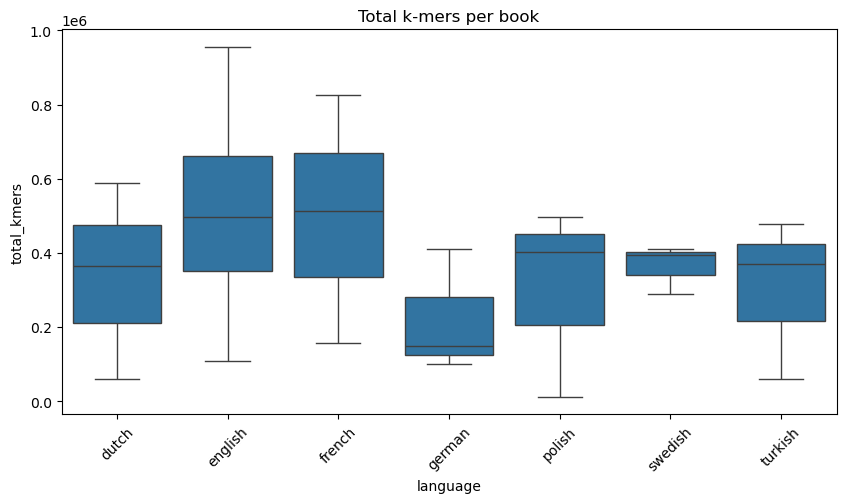

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=book_sizes,
    x="language",
    y="total_kmers"
)

plt.xticks(rotation=45)

plt.title("Total k-mers per book")

plt.show()

In [26]:
matrix = df.pivot_table(
    index=["language", "book"],
    columns="kmer",
    values="frequency",
    fill_value=0
)

In [27]:
feature_var = matrix.var()

nonzero_features = feature_var[feature_var > 0].index

matrix_filtered = matrix[nonzero_features]

print(matrix.shape)
print(matrix_filtered.shape)

(22, 10601)
(22, 10601)


In [28]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(matrix_filtered)

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

coords = pca.fit_transform(X_scaled)

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "language": matrix_filtered.index.get_level_values(0),
    "book": matrix_filtered.index.get_level_values(1)
})

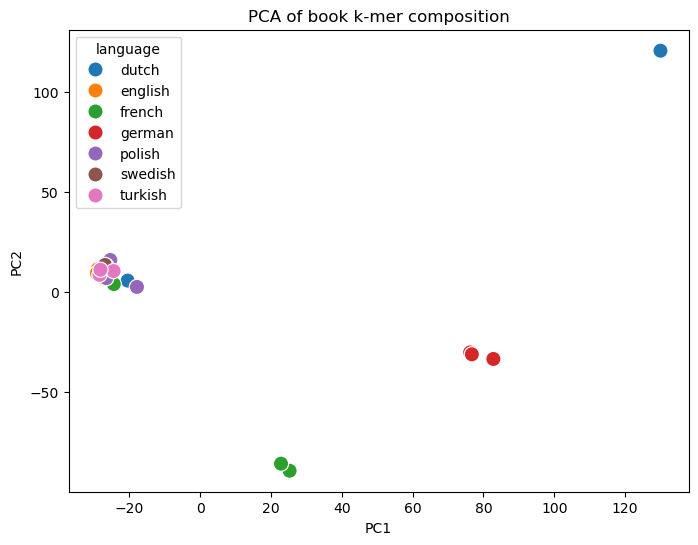

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="language",
    s=120
)

plt.title("PCA of book k-mer composition")

plt.show()

In [33]:
pca.explained_variance_ratio_

array([0.20339919, 0.148125  ])

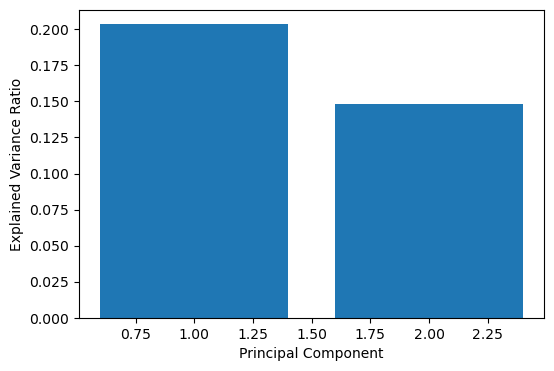

In [34]:
plt.figure(figsize=(6,4))

plt.bar(
    range(1, 3),
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.show()

In [35]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=matrix_filtered.columns,
    columns=["PC1", "PC2"]
)

loadings.head()

,PC1,PC2
kmer,,
AAA,0.013075,0.009973
AAB,0.008418,-0.007488
AAC,0.002381,-0.016887
AAD,0.013299,0.015019
AAE,0.002311,-0.011941


In [36]:
loadings["abs_pc1"] = loadings["PC1"].abs()

top_pc1 = loadings.sort_values(
    "abs_pc1",
    ascending=False
).head(20)

top_pc1

,PC1,PC2,abs_pc1
kmer,,,
END,0.021074,0.003126,0.021074
NDE,0.020878,0.003498,0.020878
RDE,0.020825,-0.000110,0.020825
NEN,0.020781,-0.000299,0.020781
MDE,0.020742,0.005580,0.020742
ENA,0.020618,-0.000359,0.020618
LEN,0.020615,-0.001019,0.020615
NZE,0.020573,0.006606,0.020573
ENR,0.020555,0.004802,0.020555


In [37]:
top_features = (
    matrix_filtered.var()
    .sort_values(ascending=False)
    .head(50)
    .index
)

heatmap_data = matrix_filtered[top_features]

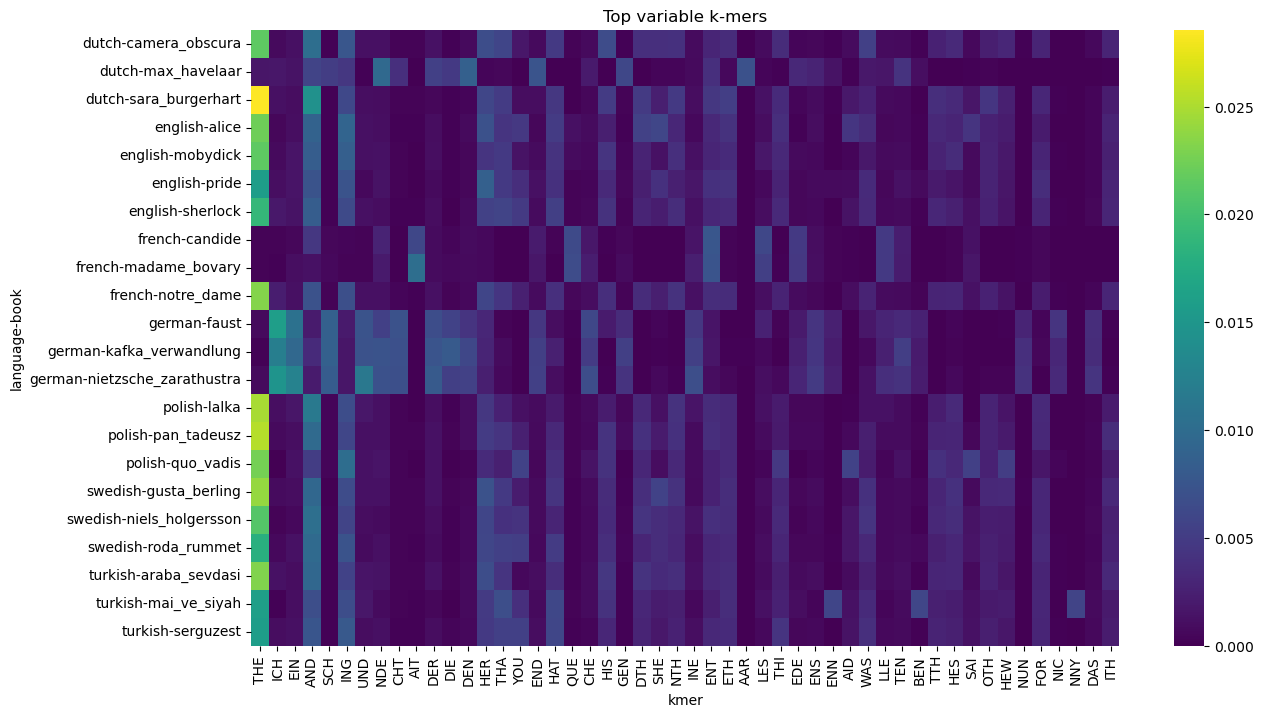

In [38]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="viridis"
)

plt.title("Top variable k-mers")

plt.show()

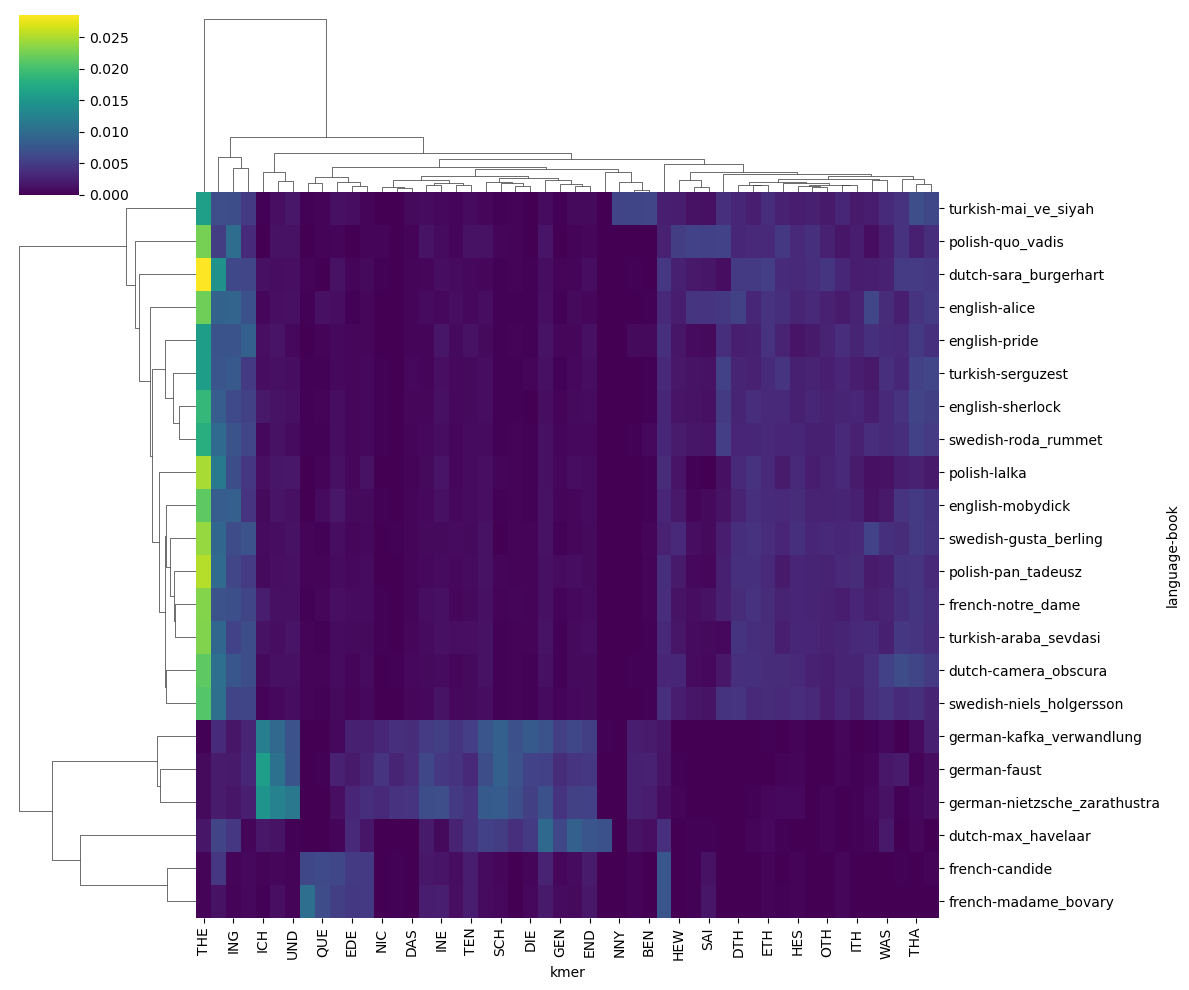

In [39]:
sns.clustermap(
    heatmap_data,
    cmap="viridis",
    figsize=(12,10)
)

In [40]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=matrix_filtered.columns,
    columns=["PC1", "PC2"]
)

loadings["abs_pc1"] = loadings["PC1"].abs()

top_pc1 = loadings.sort_values(
    "abs_pc1",
    ascending=False
).head(20)

top_pc1

,PC1,PC2,abs_pc1
kmer,,,
END,0.021074,0.003126,0.021074
NDE,0.020878,0.003498,0.020878
RDE,0.020825,-0.000110,0.020825
NEN,0.020781,-0.000299,0.020781
MDE,0.020742,0.005580,0.020742
ENA,0.020618,-0.000359,0.020618
LEN,0.020615,-0.001019,0.020615
NZE,0.020573,0.006606,0.020573
ENR,0.020555,0.004802,0.020555


In [41]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

In [42]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=matrix_filtered.columns,
    columns=["PC1", "PC2"]
)

loadings.head()

,PC1,PC2
kmer,,
AAA,0.013075,0.009973
AAB,0.008418,-0.007488
AAC,0.002381,-0.016887
AAD,0.013299,0.015019
AAE,0.002311,-0.011942


In [43]:
loadings["abs_PC1"] = loadings["PC1"].abs()

top_pc1 = (
    loadings
    .sort_values("abs_PC1", ascending=False)
    .head(20)
)

top_pc1

,PC1,PC2,abs_PC1
kmer,,,
END,0.021074,0.003126,0.021074
NDE,0.020878,0.003498,0.020878
RDE,0.020825,-0.000110,0.020825
NEN,0.020781,-0.000299,0.020781
MDE,0.020742,0.005580,0.020742
ENA,0.020618,-0.000359,0.020618
LEN,0.020615,-0.001019,0.020615
NZE,0.020573,0.006606,0.020573
ENR,0.020555,0.004802,0.020555


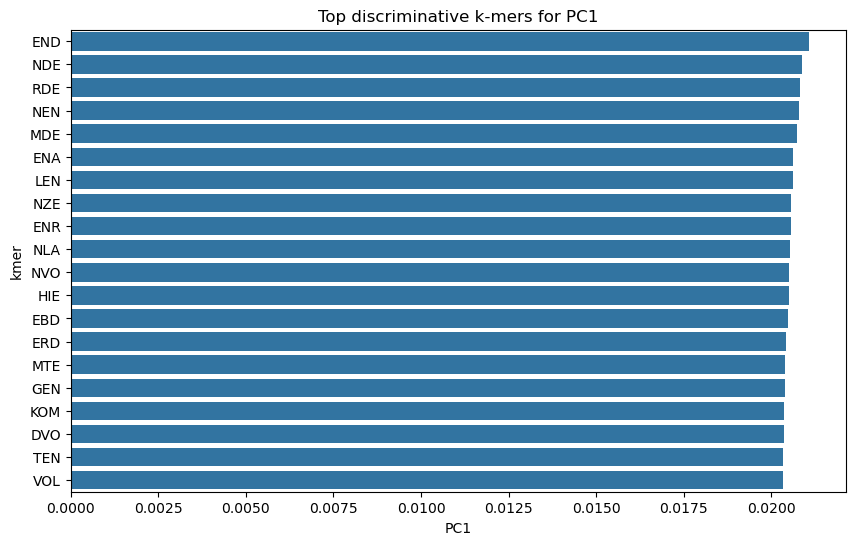

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_pc1.reset_index(),
    x="PC1",
    y="kmer"
)

plt.title("Top discriminative k-mers for PC1")

plt.show()

In [45]:
loadings["abs_PC2"] = loadings["PC2"].abs()

top_pc2 = (
    loadings
    .sort_values("abs_PC2", ascending=False)
    .head(20)
)

top_pc2

,PC1,PC2,abs_PC1,abs_PC2
kmer,,,,
DAG,-0.000487,0.022758,0.000487,0.022758
NTW,0.005571,0.021778,0.005571,0.021778
HET,-0.003402,0.021777,0.003402,0.021777
GHE,-0.003592,0.021736,0.003592,0.021736
ELY,0.001889,0.021631,0.001889,0.021631
KWI,-0.004468,0.021631,0.004468,0.021631
OVE,-0.007968,0.021459,0.007968,0.021459
EFT,0.005585,0.021396,0.005585,0.021396
KEE,0.002354,0.021328,0.002354,0.021328


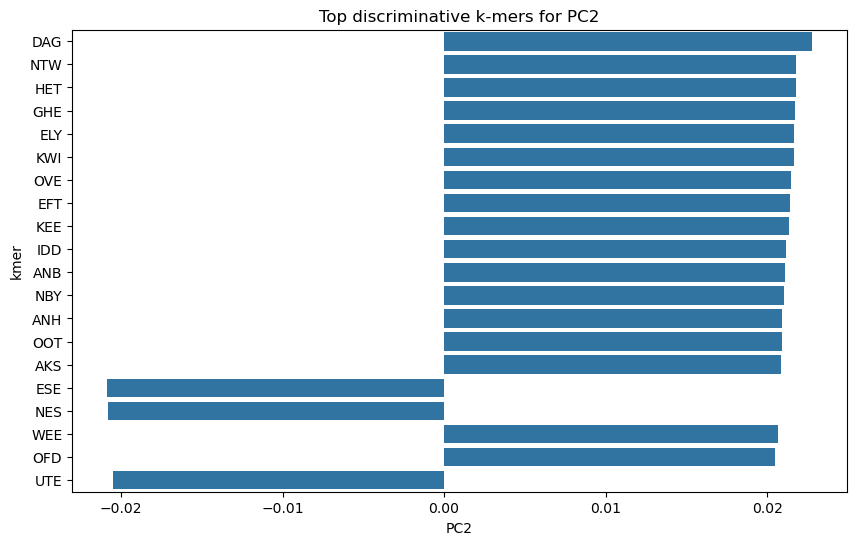

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_pc2.reset_index(),
    x="PC2",
    y="kmer"
)

plt.title("Top discriminative k-mers for PC2")

plt.show()